# Notebook 02 — Traditional Baseline: Peak Detection

The **baseline** method uses classical signal processing — no learning required.  
It serves as the benchmark against which the CNN and TCN are compared.

**Pipeline:**
1. Apply a **Savitzky-Golay filter** to smooth noise while preserving peak shape
2. Call **`scipy.signal.find_peaks`** with amplitude, distance, and prominence thresholds
3. Place a `1.0` in the output pulse vector at each detected peak

Goals of this notebook:
1. Understand the signal and what axle peaks look like
2. Step through the baseline pipeline visually
3. Tune the detection thresholds on the validation set
4. Evaluate on the test set and record final metrics


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

from src.dataset  import build_datasets
from src.baseline import signal_to_pulse_peaks, tune_threshold
from src.evaluate import axle_level_metrics, pulses_to_peaks

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

JSON_PATH = '../axle_data.json/axle_data.json'
SEED      = 42
TOL       = 5

train_ds, val_ds, test_ds = build_datasets(JSON_PATH, seed=SEED)
print(f'Train: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}')


Loaded 32,141 records from axle_data.json
  Train: 25,712  |  Val: 3,214  |  Test: 3,215
  Signal stats (train) — mean: 0.0322, std: 0.1866
Train: 25,712  |  Val: 3,214  |  Test: 3,215


## 1. What does a signal look like?

A single vehicle crossing produces a 1,300-sample strain signal. Ground-truth axle positions are marked with `1.0` in the `pulses` array.


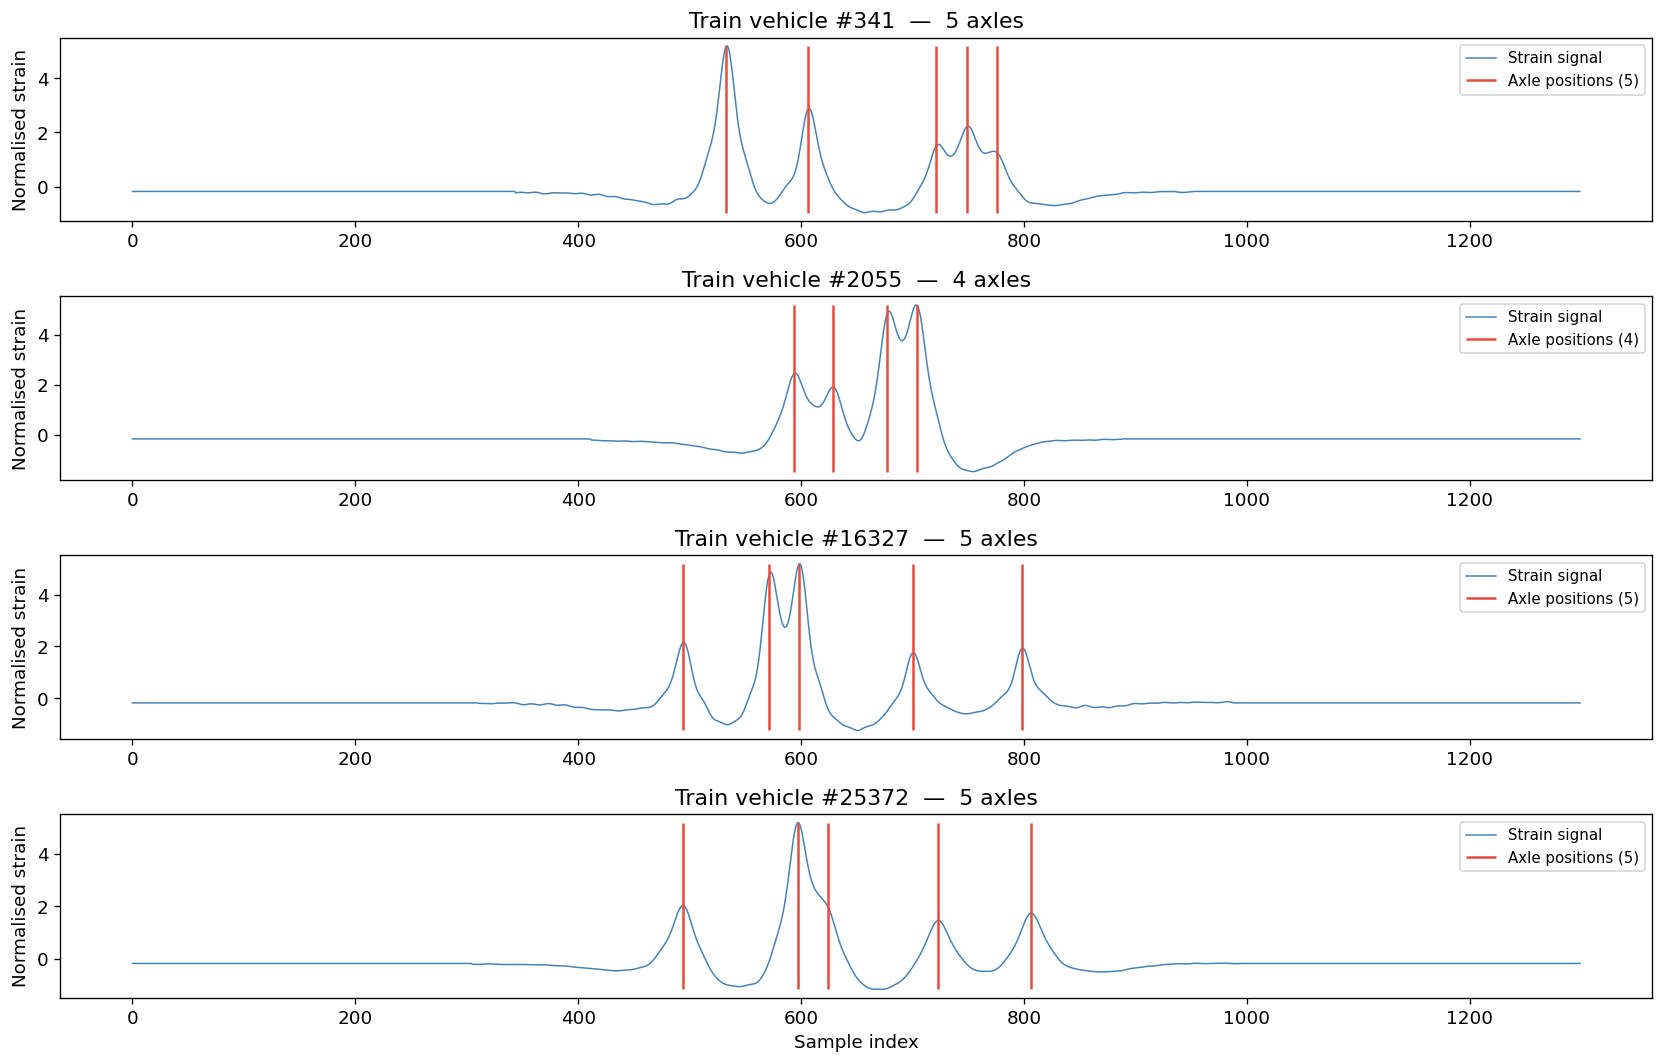

In [2]:
np.random.seed(SEED)
sample_indices = np.random.choice(len(train_ds), 4, replace=False)

fig, axes = plt.subplots(4, 1, figsize=(14, 9))
for ax, idx in zip(axes, sample_indices):
    sig, pulse = train_ds[idx]
    sig   = sig.squeeze(0).numpy()
    pulse = pulse.numpy()
    true_peaks = pulses_to_peaks(pulse, threshold=0.5)

    ax.plot(sig, color='steelblue', linewidth=0.9, label='Strain signal')
    ax.vlines(true_peaks, sig.min(), sig.max(), colors='#e74c3c',
              linewidth=1.5, label=f'Axle positions ({len(true_peaks)})')
    ax.set_ylabel('Normalised strain')
    ax.set_title(f'Train vehicle #{idx}  —  {len(true_peaks)} axles')
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Sample index')
plt.tight_layout()
plt.show()


## 2. Step-by-step pipeline on one signal

Showing each stage of the baseline: raw → smoothed → peaks detected.


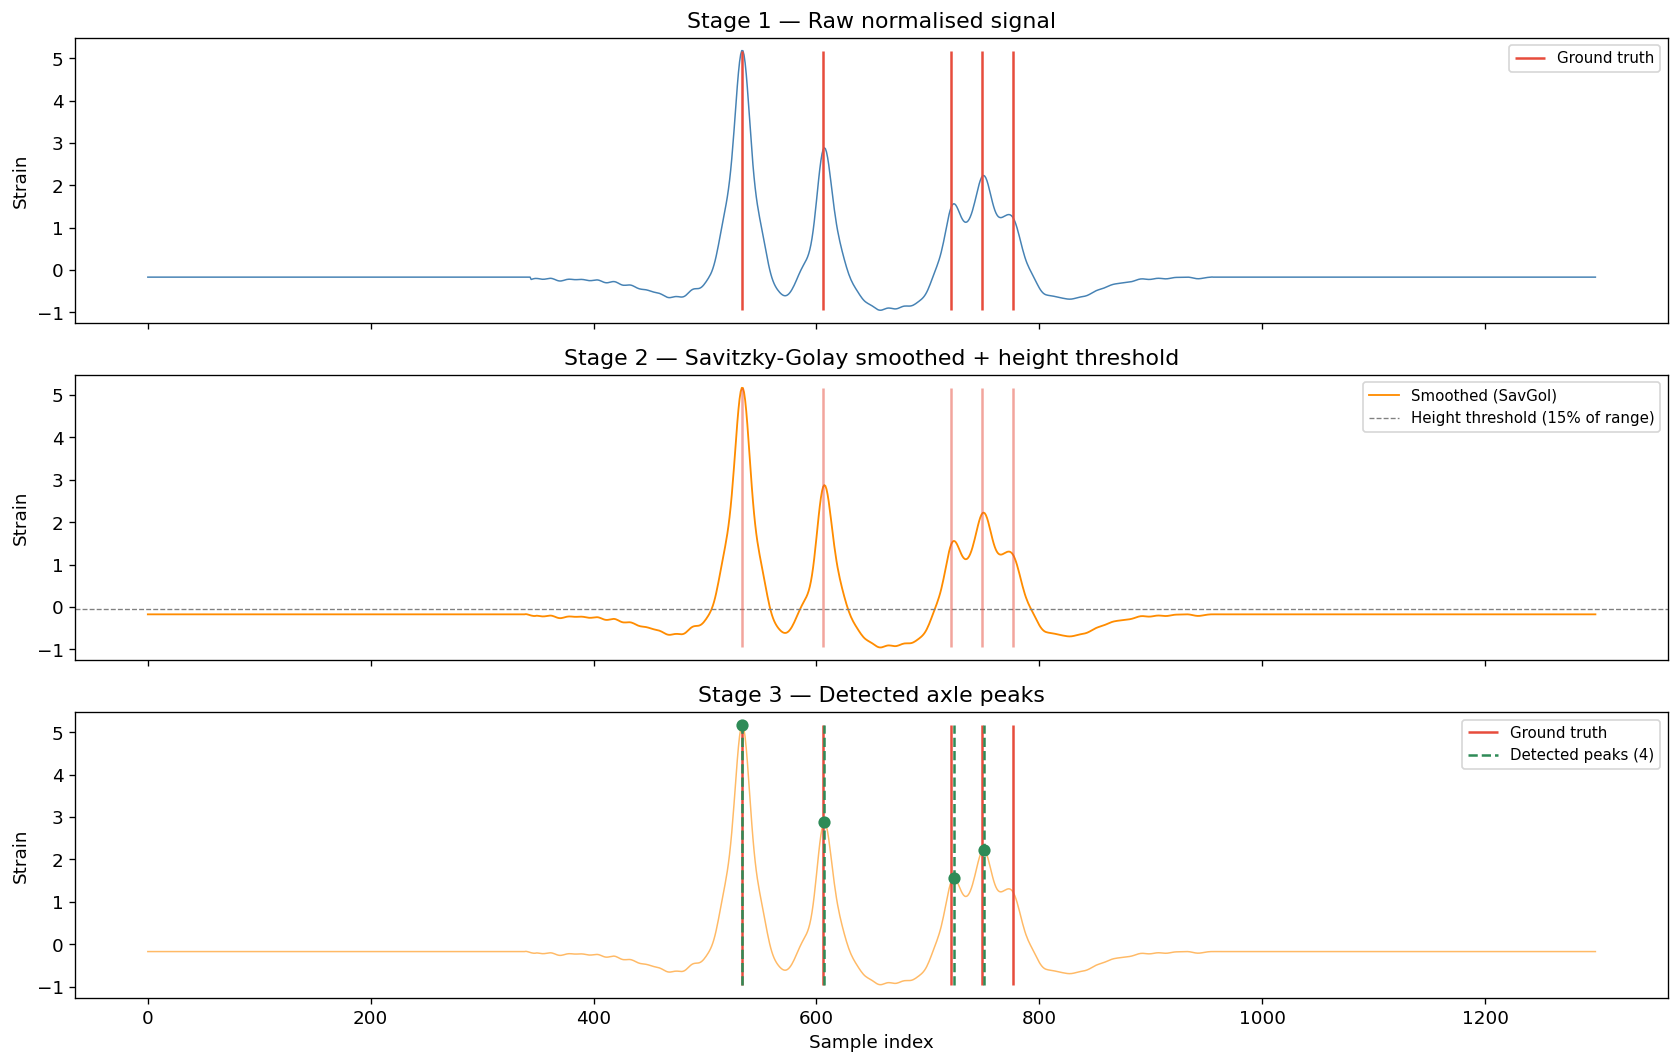

Ground truth: 5 axles at [533 606 721 749 776]
Detected    : 4 peaks at [533 607 723 750]


In [3]:
# Pick one example to walk through
ex_sig, ex_pulse = train_ds[sample_indices[0]]
ex_sig   = ex_sig.squeeze(0).numpy()
ex_pulse = ex_pulse.numpy()
true_peaks = pulses_to_peaks(ex_pulse, threshold=0.5)

# --- Stage 1: Savitzky-Golay smoothing ---
smoothed = savgol_filter(ex_sig, window_length=11, polyorder=2)

# --- Stage 2: find_peaks thresholds ---
sig_range  = float(smoothed.max() - smoothed.min()) + 1e-8
height     = smoothed.min() + 0.15 * sig_range
prominence = 0.05 * sig_range
peaks, props = find_peaks(smoothed, height=height, distance=20, prominence=prominence)

# --- Plot all three stages ---
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Stage 1: raw signal
axes[0].plot(ex_sig, color='steelblue', linewidth=0.9)
axes[0].vlines(true_peaks, ex_sig.min(), ex_sig.max(), colors='#e74c3c', linewidth=1.5, label='Ground truth')
axes[0].set_title('Stage 1 — Raw normalised signal')
axes[0].set_ylabel('Strain'); axes[0].legend(fontsize=9)

# Stage 2: smoothed signal with threshold
axes[1].plot(smoothed, color='darkorange', linewidth=1.1, label='Smoothed (SavGol)')
axes[1].axhline(height, color='grey', linestyle='--', linewidth=0.8, label=f'Height threshold ({0.15:.0%} of range)')
axes[1].vlines(true_peaks, smoothed.min(), smoothed.max(), colors='#e74c3c', linewidth=1.5, alpha=0.5)
axes[1].set_title('Stage 2 — Savitzky-Golay smoothed + height threshold')
axes[1].set_ylabel('Strain'); axes[1].legend(fontsize=9)

# Stage 3: detected peaks
axes[2].plot(smoothed, color='darkorange', linewidth=0.9, alpha=0.6)
axes[2].vlines(true_peaks, smoothed.min(), smoothed.max(), colors='#e74c3c', linewidth=1.5, label='Ground truth')
axes[2].vlines(peaks,      smoothed.min(), smoothed.max(), colors='seagreen',  linewidth=1.5, linestyle='--', label=f'Detected peaks ({len(peaks)})')
axes[2].scatter(peaks, smoothed[peaks], color='seagreen', zorder=5, s=40)
axes[2].set_title('Stage 3 — Detected axle peaks')
axes[2].set_xlabel('Sample index'); axes[2].set_ylabel('Strain'); axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Ground truth: {len(true_peaks)} axles at {true_peaks}')
print(f'Detected    : {len(peaks)} peaks at {peaks}')


## 3. Threshold tuning on the validation set

The baseline has three tunable parameters: `height_factor`, `distance`, and `prominence_factor`.  
We sweep a grid on the validation set and pick the combination that maximises F1.


In [4]:
val_signals = [val_ds[i][0].squeeze(0).numpy() for i in range(len(val_ds))]
val_pulses  = [val_ds[i][1].numpy()             for i in range(len(val_ds))]

best = tune_threshold(val_signals, val_pulses, tolerance=TOL)
print('Best parameters found:')
for k, v in best.items():
    print(f'  {k}: {v}')


Best baseline params: {'height_factor': 0.25, 'distance': 10, 'f1': 0.9363374900133026}
Best parameters found:
  height_factor: 0.25
  distance: 10
  f1: 0.9363374900133026


## 4. Test-set evaluation


In [5]:
test_signals = [test_ds[i][0].squeeze(0).numpy() for i in range(len(test_ds))]
test_pulses  = [test_ds[i][1].numpy()             for i in range(len(test_ds))]

pred_base    = [signal_to_pulse_peaks(s) for s in test_signals]
metrics      = axle_level_metrics(test_pulses, pred_base, tolerance=TOL)

print(f"Baseline — Test set  (tolerance = {TOL} samples)")
print(f"  Precision : {metrics['precision']:.4f}")
print(f"  Recall    : {metrics['recall']:.4f}")
print(f"  F1        : {metrics['f1']:.4f}")
print(f"  MATE      : {metrics['mate']:.3f} samples")
print(f"  TP={metrics['tp']:,}   FP={metrics['fp']:,}   FN={metrics['fn']:,}")


Baseline — Test set  (tolerance = 5 samples)
  Precision : 0.9969
  Recall    : 0.8843
  F1        : 0.9372
  MATE      : 0.869 samples
  TP=12,888   FP=40   FN=1,686


## 5. Visual inspection on 6 test examples

Green lines = ground-truth axle positions. Orange dashed = baseline detections. Cases where they don't align indicate errors.


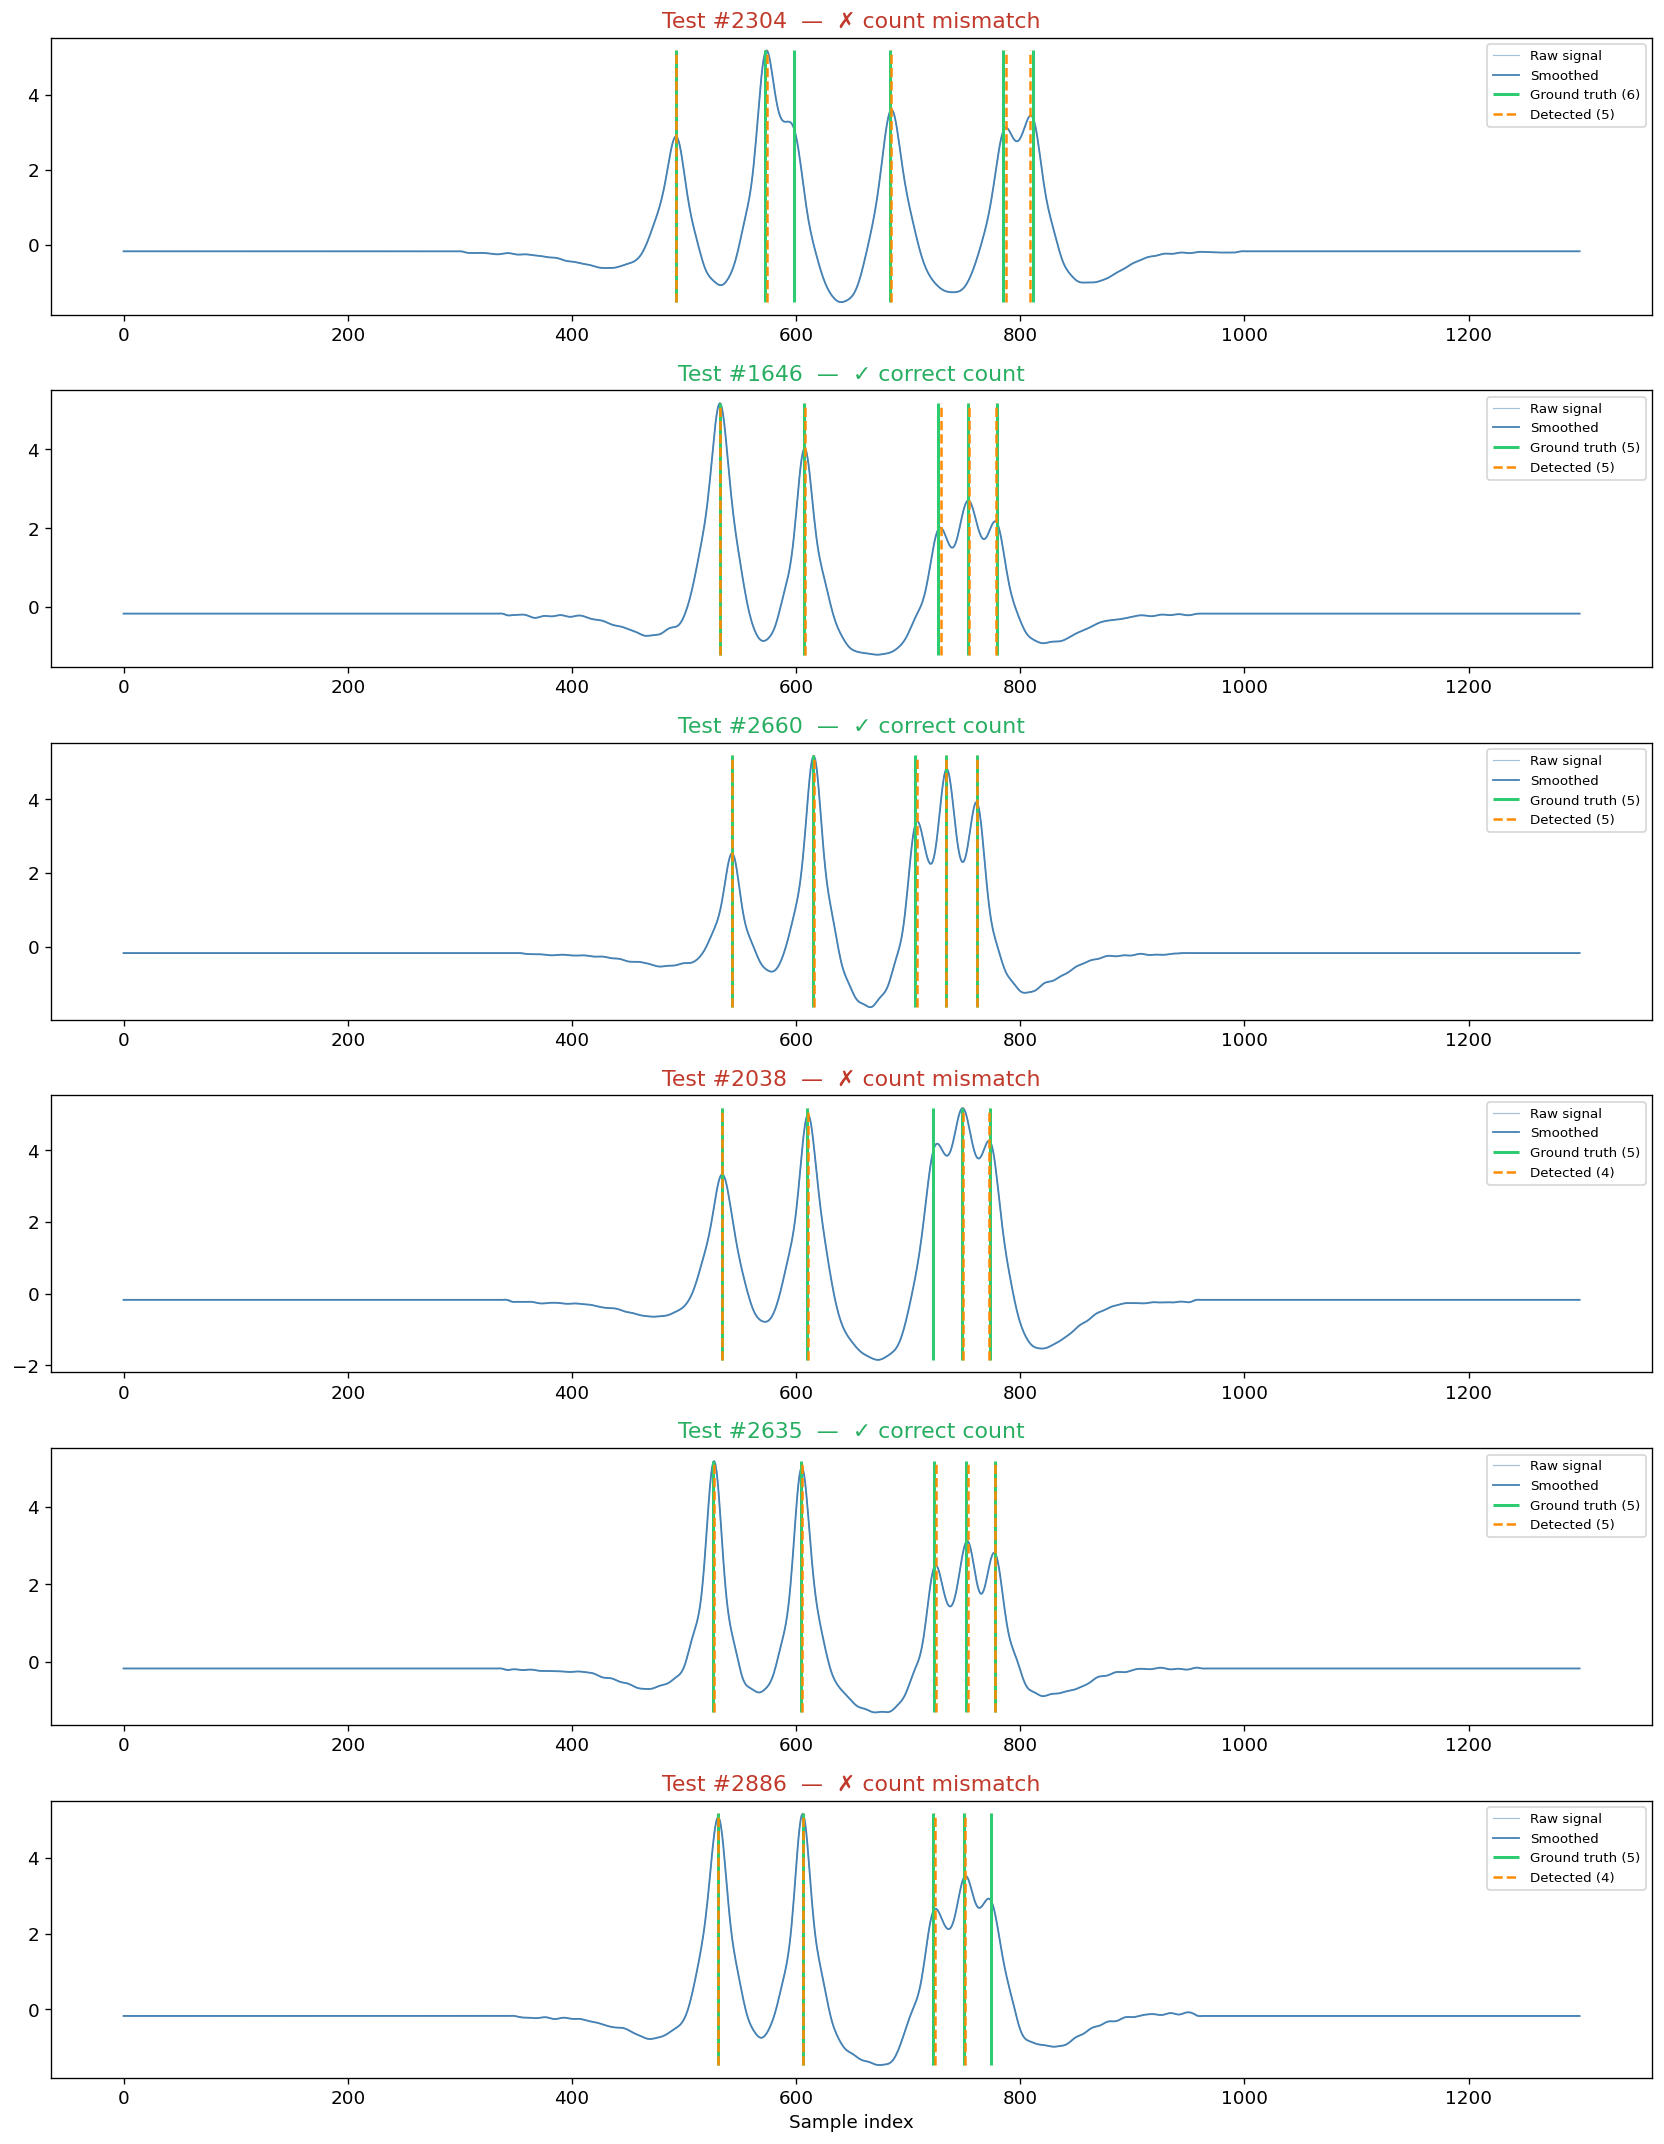

In [6]:
np.random.seed(SEED + 1)
show_idx = np.random.choice(len(test_ds), 6, replace=False)

fig, axes = plt.subplots(6, 1, figsize=(14, 3 * 6))
for ax, idx in zip(axes, show_idx):
    sig        = test_signals[idx]
    true_peaks = pulses_to_peaks(test_pulses[idx], threshold=0.5)
    pred_pulse = pred_base[idx]
    pred_peaks = pulses_to_peaks(pred_pulse,       threshold=0.5)

    smoothed = savgol_filter(sig, window_length=11, polyorder=2)

    ax.plot(sig,      color='steelblue',  linewidth=0.7, alpha=0.5, label='Raw signal')
    ax.plot(smoothed, color='steelblue',  linewidth=1.1,             label='Smoothed')
    ax.vlines(true_peaks, sig.min(), sig.max(), colors='#2ecc71',
              linewidth=1.8, label=f'Ground truth ({len(true_peaks)})')
    ax.vlines(pred_peaks, sig.min(), sig.max(), colors='darkorange',
              linewidth=1.5, linestyle='--', label=f'Detected ({len(pred_peaks)})')

    match = len(true_peaks) == len(pred_peaks)
    ax.set_title(f'Test #{idx}  —  {"✓ correct count" if match else "✗ count mismatch"}',
                 color='#27ae60' if match else '#c0392b')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Sample index')
plt.tight_layout()
plt.show()
